# вариант 1

### Модель временного ряда:

$$
y_t = (level_t + trend_t) \cdot seasonality_t
$$

### Обновление уровня (level):

$$
level_t = \alpha \cdot \frac{y_t}{season_t} + (1 - \alpha) \cdot (level_{t-1} + trend_{t-1})
$$

$$
\text{новый уровень} = \alpha \cdot (\text{наблюдение без сезонности}) + (1 - \alpha) \cdot (\text{старый уровень} + \text{тренд})
$$

### Обновление тренда:

$$
trend_t = \beta \cdot (level_t - level_{t-1}) + (1 - \beta) \cdot trend_{t-1}
$$

$$
\text{новый тренд} = \beta \cdot (\text{изменение уровня}) + (1 - \beta) \cdot (\text{старый тренд})
$$

### Обновление сезонности:

$$
season_t = \gamma \cdot \frac{y_t}{level_t} + (1 - \gamma) \cdot season_{t - s}
$$

$$
\text{новая сезонность} = \gamma \cdot (\text{отклонение от уровня}) + (1 - \gamma) \cdot (\text{старая сезонность})
$$

где $ s $ — длина сезона

### Прогноз:

$$
\hat{y}_{t+m} = (level_t + m \cdot trend_t) \cdot season_{t - s + (m \bmod s)}
$$

### Обозначения:

- $ y_t $ — наблюдение  
- $ level_t $ — уровень ряда  
- $ trend_t $ — тренд  
- $ season_t $ — сезонная компонента  
- $ \alpha $ — сглаживание уровня  
- $ \beta $ — сглаживание тренда  
- $ \gamma $ — сглаживание сезонности  
- $ s $ — длина сезона

## что означают коэффициенты

- `alpha` отвечает за уровень ряда
- `beta` отвечает за тренд
- `gamma` отвечает за сезонность

Как это понимать:
- большой `alpha` делает модель более чувствительной к новым значениям
- большой `beta` заставляет тренд меняться быстрее
- большой `gamma` заставляет сезонный рисунок обновляться быстрее

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.tsa.holtwinters import ExponentialSmoothing

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.2f}'.format


In [3]:
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12,
}

month_names_ru = {
    1: 'январь',
    2: 'февраль',
    3: 'март',
    4: 'апрель',
    5: 'май',
    6: 'июнь',
    7: 'июль',
    8: 'август',
    9: 'сентябрь',
    10: 'октябрь',
    11: 'ноябрь',
    12: 'декабрь',
}

data = pd.read_csv('data.csv', sep=';', dtype=str)
data['month'] = data['date1'].map(month_map)
data['date'] = pd.to_datetime(
    dict(year=data['date2'].astype(int), month=data['month'], day=1)
)
data['x1'] = pd.to_numeric(
    data['x1'].str.replace(',', '.', regex=False),
    errors='coerce'
)

series = data.set_index('date')['x1']
train = series.dropna().copy()
future_dates = series[series.isna()].index

print(f'известных значений: {len(train)}')
print(f'месяцев для прогноза: {len(future_dates)}')

display(data[['date', 'x1']].tail(12))


известных значений: 112
месяцев для прогноза: 8


,date,x1
108,2003-01-01,51.60
109,2003-02-01,52.70
110,2003-03-01,65.00
111,2003-04-01,69.00
112,2003-05-01,NaN
113,2003-06-01,NaN
114,2003-07-01,NaN
115,2003-08-01,NaN
116,2003-09-01,NaN
117,2003-10-01,NaN


## исходный ряд


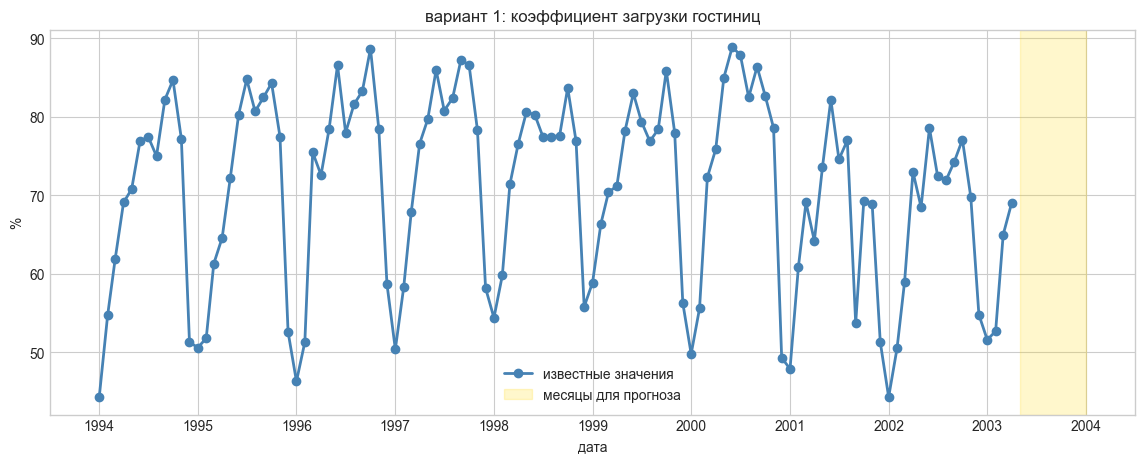

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, marker='o', linewidth=2, color='steelblue', label='известные значения')

plt.axvspan(
    future_dates[0],
    future_dates[-1] + pd.offsets.MonthEnd(1),
    color='gold',
    alpha=0.2,
    label='месяцы для прогноза'
)

plt.title('вариант 1: коэффициент загрузки гостиниц')
plt.xlabel('дата')
plt.ylabel('%')
plt.legend()
plt.show()


## базовая автоматическая модель

Сначала строим обычную модель, где коэффициенты подбираются автоматически.


In [5]:
train_for_model = train.copy()
train_for_model.index = pd.DatetimeIndex(train_for_model.index, freq='MS')

base_model = ExponentialSmoothing(
    train_for_model,
    trend='add',
    seasonal='mul',
    seasonal_periods=12,
    initialization_method='estimated'
)

base_fit = base_model.fit(optimized=True, use_brute=True)
base_fitted = pd.Series(base_fit.fittedvalues.values, index=train.index)
base_forecast = pd.Series(base_fit.forecast(len(future_dates)).values, index=future_dates)

base_mae = np.mean(np.abs(train - base_fitted))
base_rmse = np.sqrt(np.mean((train - base_fitted) ** 2))

base_table = pd.DataFrame({
    'параметр': ['alpha', 'beta', 'gamma', 'mae', 'rmse'],
    'значение': [
        base_fit.params['smoothing_level'],
        base_fit.params['smoothing_trend'],
        base_fit.params['smoothing_seasonal'],
        base_mae,
        base_rmse,
    ]
})

display(base_table)


,параметр,значение
0,alpha,0.37
1,beta,0.00
2,gamma,0.00
3,mae,2.86
4,rmse,4.08


## ручные сценарии

- что будет при маленьком и большом `alpha`
- что будет при маленьком и большом `beta`
- что будет при маленьком `gamma`
- что если добавить один спокойный сбалансированный вариант


In [6]:
scenarios = [
    {
        'сценарий': 'авто-модель',
        'alpha': float(base_fit.params['smoothing_level']),
        'beta': float(base_fit.params['smoothing_trend']),
        'gamma': float(base_fit.params['smoothing_seasonal']),
        'комментарий': 'коэффициенты подобраны самой моделью'
    },
    {
        'сценарий': 'низкий alpha',
        'alpha': 0.005,
        'beta': 0.05,
        'gamma': 0.10,
        'комментарий': 'уровень меняется медленно'
    },
    {
        'сценарий': 'высокий alpha',
        'alpha': 0.95,
        'beta': 0.05,
        'gamma': 0.10,
        'комментарий': 'уровень резко реагирует на новые точки'
    },
    {
        'сценарий': 'низкий beta',
        'alpha': 0.35,
        'beta': 0.00,
        'gamma': 0.10,
        'комментарий': 'тренд почти не меняется'
    },
    {
        'сценарий': 'высокий beta',
        'alpha': 0.35,
        'beta': 0.80,
        'gamma': 0.10,
        'комментарий': 'тренд меняется заметно быстрее'
    },
    {
        'сценарий': 'низкий gamma',
        'alpha': 0.35,
        'beta': 0.05,
        'gamma': 0.00,
        'комментарий': 'сезонность почти не перестраивается'
    },
    {
        'сценарий': 'сбалансированный',
        'alpha': 0.45,
        'beta': 0.10,
        'gamma': 0.15,
        'комментарий': 'умеренная реакция по всем частям модели'
    },
]

scenarios_df = pd.DataFrame(scenarios)
display(scenarios_df)


,сценарий,alpha,beta,gamma,комментарий
0,авто-модель,0.37,0.00,0.00,коэффициенты подобраны самой моделью
1,низкий alpha,0.01,0.05,0.10,уровень меняется медленно
2,высокий alpha,0.95,0.05,0.10,уровень резко реагирует на новые точки
3,низкий beta,0.35,0.00,0.10,тренд почти не меняется
4,высокий beta,0.35,0.80,0.10,тренд меняется заметно быстрее
5,низкий gamma,0.35,0.05,0.00,сезонность почти не перестраивается
6,сбалансированный,0.45,0.10,0.15,умеренная реакция по всем частям модели


In [7]:
def run_manual_scenario(alpha, beta, gamma):
    model = ExponentialSmoothing(
        train_for_model,
        trend='add',
        seasonal='mul',
        seasonal_periods=12,
        initialization_method='estimated'
    )

    fit = model.fit(
        optimized=False,
        smoothing_level=alpha,
        smoothing_trend=beta,
        smoothing_seasonal=gamma,
    )

    fitted = pd.Series(fit.fittedvalues.values, index=train.index)
    forecast = pd.Series(fit.forecast(len(future_dates)).values, index=future_dates)

    mae = np.mean(np.abs(train - fitted))
    rmse = np.sqrt(np.mean((train - fitted) ** 2))

    return fit, fitted, forecast, mae, rmse

scenario_results = {}
comparison_rows = []

for scenario in scenarios:
    name = scenario['сценарий']

    if name == 'авто-модель':
        fit = base_fit
        fitted = base_fitted
        forecast = base_forecast
        mae = base_mae
        rmse = base_rmse
    else:
        fit, fitted, forecast, mae, rmse = run_manual_scenario(
            scenario['alpha'],
            scenario['beta'],
            scenario['gamma']
        )

    scenario_results[name] = {
        'fit': fit,
        'fitted': fitted,
        'forecast': forecast,
        'mae': mae,
        'rmse': rmse,
        'alpha': scenario['alpha'],
        'beta': scenario['beta'],
        'gamma': scenario['gamma'],
        'комментарий': scenario['комментарий'],
    }

    comparison_rows.append({
        'сценарий': name,
        'alpha': scenario['alpha'],
        'beta': scenario['beta'],
        'gamma': scenario['gamma'],
        'MAE': mae,
        'RMSE': rmse,
        'комментарий': scenario['комментарий'],
    })

comparison_table = pd.DataFrame(comparison_rows).sort_values('RMSE').reset_index(drop=True)
display(comparison_table)


,сценарий,alpha,beta,gamma,MAE,RMSE,комментарий
0,авто-модель,0.37,0.00,0.00,2.86,4.08,коэффициенты подобраны самой моделью
1,низкий gamma,0.35,0.05,0.00,3.09,4.46,сезонность почти не перестраивается
2,низкий beta,0.35,0.00,0.10,3.09,4.47,тренд почти не меняется
3,сбалансированный,0.45,0.10,0.15,3.33,4.70,умеренная реакция по всем частям модели
4,высокий alpha,0.95,0.05,0.10,3.70,5.14,уровень резко реагирует на новые точки
5,высокий beta,0.35,0.80,0.10,4.22,5.88,тренд меняется заметно быстрее
6,низкий alpha,0.01,0.05,0.10,5.16,7.33,уровень меняется медленно


## как сценарии описывают историю

На этом графике чёрная линия — реальные данные.
Цветные линии — то, как каждая модель пытается описать уже известную историю.

Если линия идёт ближе к реальным значениям, значит сценарий описывает историю лучше.


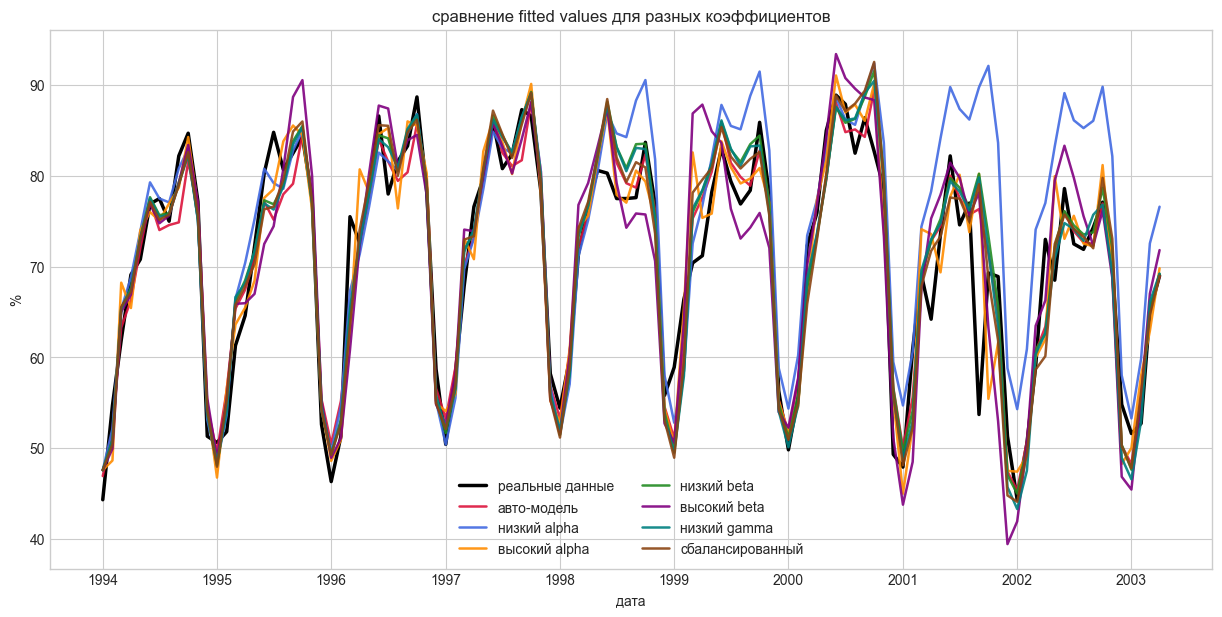

In [8]:
plt.figure(figsize=(15, 7))
plt.plot(train.index, train.values, color='black', linewidth=2.5, label='реальные данные')

colors = {
    'авто-модель': 'crimson',
    'низкий alpha': 'royalblue',
    'высокий alpha': 'darkorange',
    'низкий beta': 'forestgreen',
    'высокий beta': 'purple',
    'низкий gamma': 'teal',
    'сбалансированный': 'saddlebrown',
}

for name, result in scenario_results.items():
    plt.plot(
        result['fitted'].index,
        result['fitted'].values,
        linewidth=1.8,
        alpha=0.9,
        label=name,
        color=colors[name]
    )

plt.title('сравнение fitted values для разных коэффициентов')
plt.xlabel('дата')
plt.ylabel('%')
plt.legend(ncol=2)
plt.show()


## как сценарии меняют прогноз

Теперь смотрим только на будущие 8 месяцев.
Здесь хорошо видно, как разные коэффициенты меняют форму прогноза.


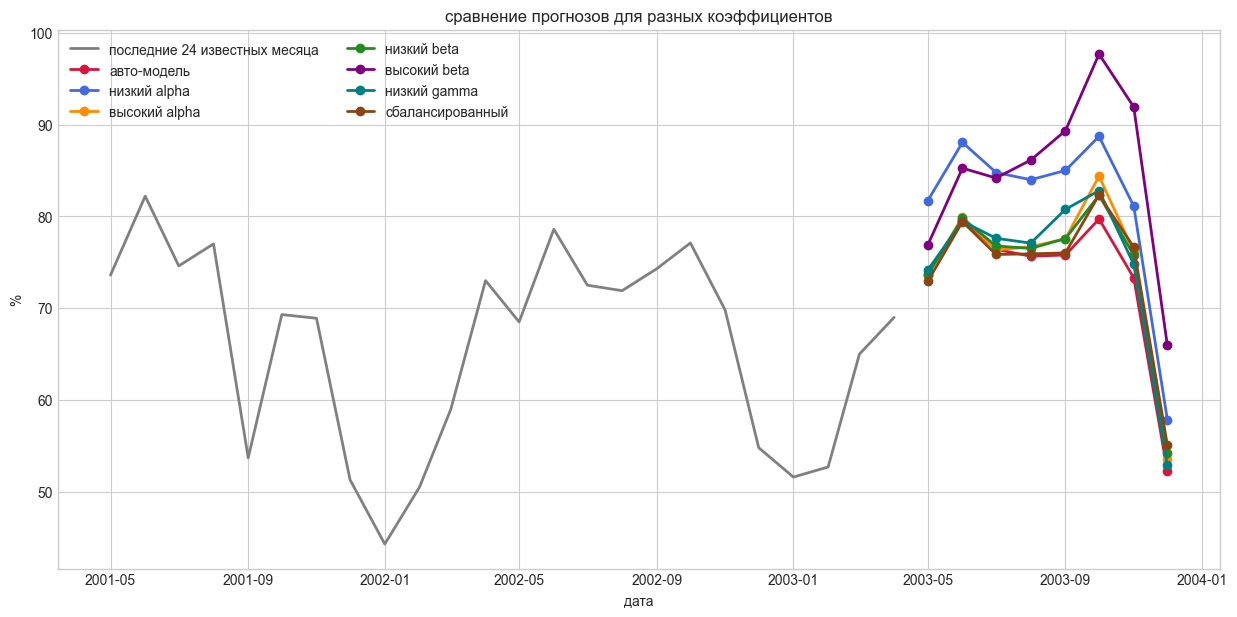

In [9]:
plt.figure(figsize=(15, 7))
plt.plot(train.index[-24:], train.values[-24:], color='gray', linewidth=2, label='последние 24 известных месяца')

for name, result in scenario_results.items():
    plt.plot(
        result['forecast'].index,
        result['forecast'].values,
        marker='o',
        linewidth=2,
        label=name,
        color=colors[name]
    )

plt.title('сравнение прогнозов для разных коэффициентов')
plt.xlabel('дата')
plt.ylabel('%')
plt.legend(ncol=2)
plt.show()


## лучший сценарий по rmse

Возьмём сценарий с наименьшим `RMSE` и покажем его прогноз отдельно.
Так проще увидеть, какой вариант оказался самым удачным внутри нашего набора.


лучший сценарий по rmse: авто-модель


,дата,"прогноз, %"
0,май 2003,73.75
1,июнь 2003,79.61
2,июль 2003,76.41
3,август 2003,75.65
4,сентябрь 2003,75.79
5,октябрь 2003,79.72
6,ноябрь 2003,73.30
7,декабрь 2003,52.31


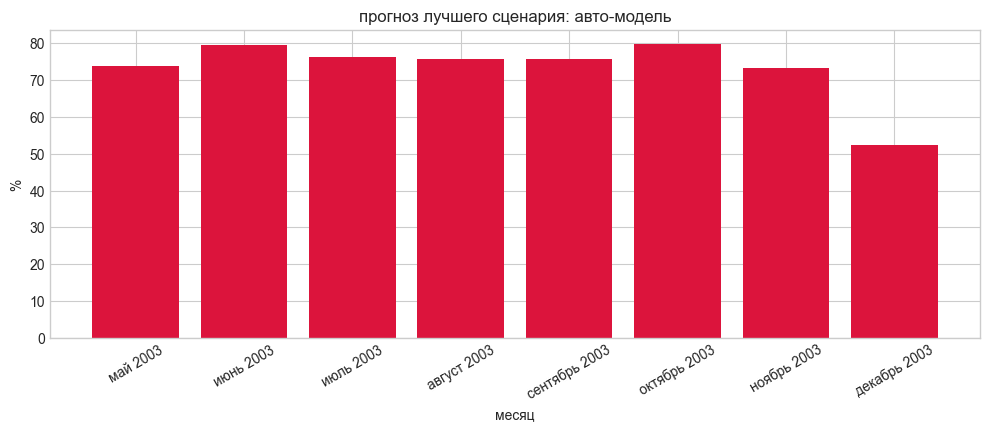

In [10]:
best_name = comparison_table.loc[0, 'сценарий']
best_result = scenario_results[best_name]

print(f'лучший сценарий по rmse: {best_name}')

best_forecast_table = pd.DataFrame({
    'дата': [f"{month_names_ru[d.month]} {d.year}" for d in future_dates],
    'прогноз, %': np.round(best_result['forecast'].values, 2)
})

display(best_forecast_table)

plt.figure(figsize=(12, 4))
plt.bar(best_forecast_table['дата'], best_forecast_table['прогноз, %'], color=colors[best_name])
plt.title(f'прогноз лучшего сценария: {best_name}')
plt.xlabel('месяц')
plt.ylabel('%')
plt.xticks(rotation=30)
plt.show()


## короткие наблюдения

Что обычно видно в таких экспериментах:
- при большом `alpha` модель быстрее бросается за новыми значениями
- при маленьком `alpha` модель ведёт себя спокойнее
- большой `beta` делает линию тренда более подвижной
- маленький `gamma` почти не даёт сезонности меняться

Автоматически подобранные коэффициенты часто оказываются устойчивее, потому что модель подбирает их под сам ряд, а не берёт заранее заданные числа.


## вывод

В этом ноутбуке мы специально меняли `alpha`, `beta`, `gamma` и смотрели, как меняется поведение модели Хольта-Винтерса.

Эксперимент показывает, что коэффициенты действительно сильно влияют на результат:
- одни наборы делают модель спокойнее
- другие делают её более резкой и чувствительной
- автоматический подбор обычно даёт более аккуратную отправную точку

Такой эксперимент полезен, потому что помогает не просто запустить готовую модель, а понять, что именно происходит внутри неё.
